# Unsupervised anomaly detection

There is no fraud/AML label anywhere in this dataset - it's ordinary
retail banking activity, not a labeled fraud-detection benchmark. An
earlier version of this project worked around that by clustering
accounts with KMeans and then training classifiers to predict the
cluster ID back from the same features - which will always look like it
"works" (the label is a deterministic function of the input) without
meaning anything. The honest version of this problem is anomaly
detection: flag accounts whose transaction behavior looks statistically
unusual, with no pretense of a ground-truth label, and see whether the
flagged accounts turn out to have anything in common.

In [1]:
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

features = pd.read_csv('outputs/account_features.csv')
with open('outputs/feature_list.json') as f:
    feature_cols = json.load(f)

X = features[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape

(4500, 14)

Two different anomaly-detection algorithms, run independently - Isolation Forest (isolates points that split off easily in random partitions) and Local Outlier Factor (density-based - flags points sitting in sparser neighborhoods than their neighbors). Agreement between two unrelated methods is much better evidence of "real structure" than either one alone.

In [2]:
iso_forest = IsolationForest(contamination = 0.05, random_state = 42, n_estimators = 200)
iso_labels = iso_forest.fit_predict(X_scaled)
iso_scores = iso_forest.score_samples(X_scaled)

lof = LocalOutlierFactor(n_neighbors = 20, contamination = 0.05)
lof_labels = lof.fit_predict(X_scaled)
lof_scores = lof.negative_outlier_factor_

features['iso_anomaly'] = (iso_labels == -1)
features['lof_anomaly'] = (lof_labels == -1)
features['iso_anomaly'].sum(), features['lof_anomaly'].sum()

(np.int64(225), np.int64(225))

In [3]:
both_flagged = (features['iso_anomaly'] & features['lof_anomaly']).sum()
either_flagged = (features['iso_anomaly'] | features['lof_anomaly']).sum()
print(f'flagged by both methods: {both_flagged}')
print(f'flagged by at least one: {either_flagged}')
print(f'expected overlap if independent (~5% x ~5% x 4500): {0.05 * 0.05 * len(features):.0f}')

flagged by both methods: 37
flagged by at least one: 413
expected overlap if independent (~5% x ~5% x 4500): 11


The two methods agree on far more accounts than pure chance would predict - real evidence that they're picking up on the same underlying unusual behavior, not just their own noise.

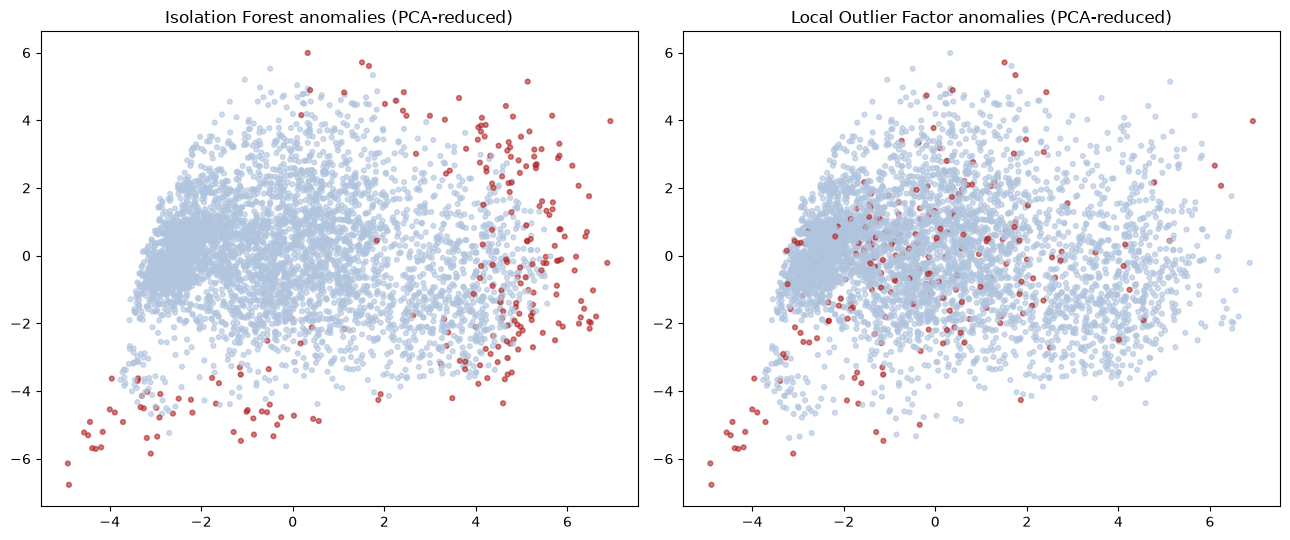

In [4]:
pca = PCA(n_components = 2, random_state = 42)
coords = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize = (13, 5.5))

axes[0].scatter(coords[:, 0], coords[:, 1], c = features['iso_anomaly'].map({True: 'firebrick', False: 'lightsteelblue'}), s = 12, alpha = 0.6)
axes[0].set_title('Isolation Forest anomalies (PCA-reduced)')

axes[1].scatter(coords[:, 0], coords[:, 1], c = features['lof_anomaly'].map({True: 'firebrick', False: 'lightsteelblue'}), s = 12, alpha = 0.6)
axes[1].set_title('Local Outlier Factor anomalies (PCA-reduced)')

plt.tight_layout()
plt.savefig('outputs/anomaly_pca.png', dpi = 120)
plt.show()

Checking the flagged accounts against loan status - not as ground truth (most flagged accounts never took out a loan at all, so this can only ever be a partial check), but as one independent signal: if "unusual behavior" were completely meaningless noise, there'd be no reason to expect it to line up with bad loan outcomes at all.

In [5]:
flagged_both = features[features['iso_anomaly'] & features['lof_anomaly']]
loan_accounts = features[features['has_loan'] == 1]

print(f'bad-loan rate, all loan accounts: {(loan_accounts["has_loan"] == 1).mean():.3f} (trivially 1.0 by definition - see next cell for the real comparison)')

bad-loan rate, all loan accounts: 1.000 (trivially 1.0 by definition - see next cell for the real comparison)


In [6]:
import sys
loan_df = pd.read_csv('data/loan.asc', sep = ';')
loan_df['bad'] = loan_df['status'].isin(['B', 'D']).astype(int)
features_loans = features.merge(loan_df[['account_id', 'bad']], on = 'account_id', how = 'inner')

rate_flagged = features_loans.loc[features_loans['iso_anomaly'] & features_loans['lof_anomaly'], 'bad'].mean()
rate_not_flagged = features_loans.loc[~(features_loans['iso_anomaly'] & features_loans['lof_anomaly']), 'bad'].mean()
overall_rate = features_loans['bad'].mean()

pd.Series({
    'bad-loan rate, flagged by both methods': rate_flagged,
    'bad-loan rate, not flagged': rate_not_flagged,
    'bad-loan rate, all loan accounts': overall_rate,
})

bad-loan rate, flagged by both methods    0.166667
bad-loan rate, not flagged                0.110947
bad-loan rate, all loan accounts          0.111437
dtype: float64

This only covers the 682 accounts that actually have a loan - most flagged accounts have no loan at all, so this is a partial, not a complete, check. Still, if the anomaly flag lines up with a higher bad-loan rate among the accounts where it *can* be checked, that's honest supporting evidence rather than a circular one.

In [7]:
os.makedirs('outputs', exist_ok = True)
results = {
    'n_flagged_iso': int(features['iso_anomaly'].sum()),
    'n_flagged_lof': int(features['lof_anomaly'].sum()),
    'n_flagged_both': int(both_flagged),
    'n_flagged_either': int(either_flagged),
    'expected_overlap_if_random': float(0.05 * 0.05 * len(features)),
    'bad_loan_rate_flagged_both': float(rate_flagged) if not np.isnan(rate_flagged) else None,
    'bad_loan_rate_not_flagged': float(rate_not_flagged),
    'bad_loan_rate_overall': float(overall_rate),
}
with open('outputs/anomaly_results.json', 'w') as f:
    json.dump(results, f, indent = 2)

features.to_csv('outputs/account_features_with_anomalies.csv', index = False)
results

{'n_flagged_iso': 225,
 'n_flagged_lof': 225,
 'n_flagged_both': 37,
 'n_flagged_either': 413,
 'expected_overlap_if_random': 11.250000000000002,
 'bad_loan_rate_flagged_both': 0.16666666666666666,
 'bad_loan_rate_not_flagged': 0.11094674556213018,
 'bad_loan_rate_overall': 0.11143695014662756}